## STEP 0 — INITIAL SETUP

This step involves installing necessary libraries and setting a global random seed for reproducibility.

In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
from tqdm.notebook import tqdm
from google.colab import userdata, drive
import os

# Set global random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"Global random seed set to: {SEED}")

Global random seed set to: 42


In [3]:
# Load train.csv using pandas
df = pd.read_csv('train.csv')
print(f"Original dataset shape: {df.shape}")

# Filter to only rows where label == 1 or label == 2
df_filtered = df[df['label'].isin([1, 2])].copy()
print(f"Filtered dataset shape (labels 1 and 2): {df_filtered.shape}")

# Separate labels and pixel data
labels = df_filtered['label'].values
pixels = df_filtered.drop('label', axis=1).values

# Reshape pixel values to 28x28 float tensors, normalize to [0, 1]
# Reshape to (N, 1, 28, 28) for PyTorch CNN input (N, Channels, Height, Width)
images_np = pixels.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0

print(f"Reshaped images (numpy) tensor shape: {images_np.shape}")
print(f"Labels (numpy) array shape: {labels.shape}")

Original dataset shape: (42000, 785)
Filtered dataset shape (labels 1 and 2): (8861, 785)
Reshaped images (numpy) tensor shape: (8861, 1, 28, 28)
Labels (numpy) array shape: (8861,)


## STEP 2 — ROTATED DATASET

This step defines a custom PyTorch Dataset to generate rotated versions of the filtered MNIST images. It includes a DataLoader for batch processing and a visualization to verify the transformations.

In [4]:
class RotatedMNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

        # Generate rotation angles: 0, 30, ..., 330 degrees
        self.rotation_angles = list(range(0, 360, 30)) # 12 rotations

    def __len__(self):
        return len(self.images) * len(self.rotation_angles)

    def __getitem__(self, idx):
        original_idx = idx // len(self.rotation_angles)
        rotation_idx = idx % len(self.rotation_angles)

        image = self.images[original_idx]
        label = self.labels[original_idx]
        angle = self.rotation_angles[rotation_idx]

        # Apply rotation using torchvision.transforms.functional.rotate
        rotated_image = TF.rotate(image, angle)

        return rotated_image, torch.tensor(angle, dtype=torch.float32), label, image.squeeze() # Return original image for visualization

# Create the dataset and DataLoader
mil_dataset = RotatedMNISTDataset(images_np, labels)
mil_dataloader = DataLoader(mil_dataset, batch_size=128, shuffle=True, drop_last=True)

print(f"Total size of the rotated dataset: {len(mil_dataset)} samples")
print(f"Number of batches per epoch: {len(mil_dataloader)}")

# Get a sample from the DataLoader to check shapes
for rotated_img, angle, label, original_img in mil_dataloader:
    print(f"Sample rotated image batch shape: {rotated_img.shape}")
    print(f"Sample angle batch shape: {angle.shape}")
    print(f"Sample label batch shape: {label.shape}")
    print(f"Sample original image batch shape: {original_img.shape}")
    break

Total size of the rotated dataset: 106332 samples
Number of batches per epoch: 830
Sample rotated image batch shape: torch.Size([128, 1, 28, 28])
Sample angle batch shape: torch.Size([128])
Sample label batch shape: torch.Size([128])
Sample original image batch shape: torch.Size([128, 28, 28])


In [5]:
# Show a grid of sample images with their rotation angles
def show_images_grid(dataloader, num_samples=8):
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    axes = axes.flatten()

    # Get one batch of data
    data_iter = iter(dataloader)
    images, angles, labels, _ = next(data_iter)

    for i in range(num_samples):
        ax = axes[i]
        img = images[i].squeeze().cpu().numpy()  # Remove channel dimension and convert to numpy
        angle = angles[i].item()
        label = labels[i].item()

        ax.imshow(img, cmap='gray')
        ax.set_title(f"Label: {label}, Angle: {int(angle)}°")
        ax.axis('off')
    plt.tight_layout()
    plt.suptitle("Sample Rotated Images from Dataset", y=1.02, fontsize=16)
    plt.show()

## STEP 3 — VAE ARCHITECTURE

This step defines the Convolutional Variational Autoencoder (VAE) architecture, including the encoder, reparameterization trick, and decoder, as specified.

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28x28 -> 14x14
        self.encoder_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14x14 -> 7x7
        self.encoder_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) # 7x7 -> 7x7

        # Latent vectors mu and log_var
        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_log_var = nn.Linear(128 * 7 * 7, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.decoder_convt1 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1) # 7x7 -> 7x7
        self.decoder_convt2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1) # 7x7 -> 14x14
        self.decoder_convt3 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1) # 14x14 -> 28x28

    def encode(self, x):
        x = F.relu(self.encoder_conv1(x))
        x = F.relu(self.encoder_conv2(x))
        x = F.relu(self.encoder_conv3(x))

        x = x.view(-1, 128 * 7 * 7) # Flatten
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std) # Sample from standard normal
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 128, 7, 7) # Reshape to (Batch, Channels, Height, Width)
        x = F.relu(self.decoder_convt1(x))
        x = F.relu(self.decoder_convt2(x))
        x = torch.sigmoid(self.decoder_convt3(x)) # Sigmoid for pixel values in [0, 1]
        return x

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var

# Instantiate the VAE and print its structure
vae = VAE(latent_dim=32)
print(vae)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)
print(f"Using device: {device}")

# Test with a dummy input
dummy_input = torch.randn(1, 1, 28, 28).to(device)
reconstruction, mu, log_var = vae(dummy_input)
print(f"Dummy input shape: {dummy_input.shape}")
print(f"Reconstruction shape: {reconstruction.shape}")
print(f"Mu shape: {mu.shape}")
print(f"Log_var shape: {log_var.shape}")

VAE(
  (encoder_conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (encoder_conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (encoder_conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc_mu): Linear(in_features=6272, out_features=32, bias=True)
  (fc_log_var): Linear(in_features=6272, out_features=32, bias=True)
  (decoder_fc): Linear(in_features=32, out_features=6272, bias=True)
  (decoder_convt1): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder_convt2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (decoder_convt3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)
Using device: cuda
Dummy input shape: torch.Size([1, 1, 28, 28])
Reconstruction shape: torch.Size([1, 1, 28, 28])
Mu shape: torch.Size([1, 32])
Log_var shape: torch.Size([1, 32])


## STEP 4 — TRAINING

This step defines the VAE loss function, sets up the Adam optimizer, and trains the VAE for 30 epochs. It also plots the training loss curve.

Starting VAE training...


Epoch 1/30:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [1/30], Loss: 84.2299


Epoch 2/30:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [2/30], Loss: 84.1932


...

Epoch [28/30], Loss: 83.0052


Epoch 29/30:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [29/30], Loss: 82.9962


Epoch 30/30:   0%|          | 0/830 [00:00<?, ?it/s]

Epoch [30/30], Loss: 82.9377
Training complete.


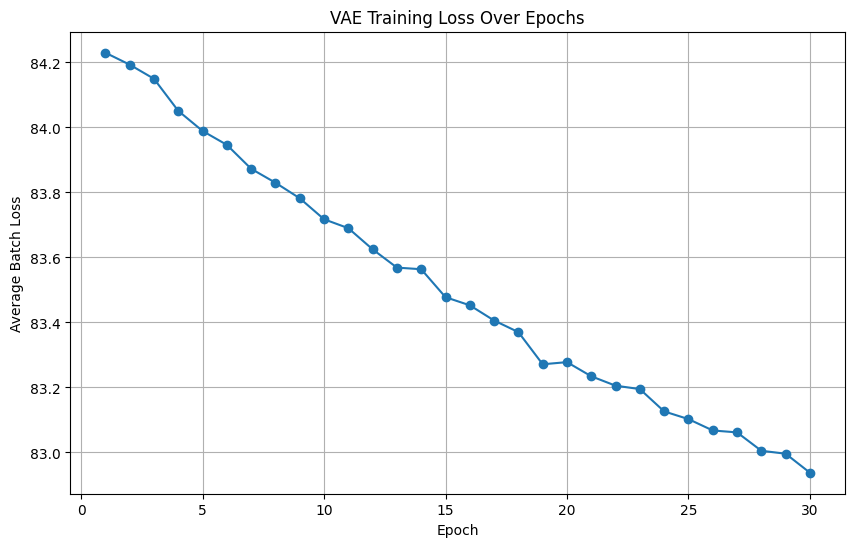

Saving trained VAE model...
Trained VAE model saved to: /content/drive/MyDrive/gsoc_symmetry_trained_model/vae_trained_model.pth


In [9]:
# VAE Loss function
def vae_loss(reconstruction, x, mu, log_var, beta=1.0):
    # Reconstruction loss (Binary Cross-Entropy)
    BCE = F.binary_cross_entropy(reconstruction, x, reduction='sum')

    # KL Divergence loss
    # KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    KL_Divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + beta * KL_Divergence

# Optimizer
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Training parameters
epochs = 30
training_losses = []

print("Starting VAE training...")
for epoch in range(epochs):
    vae.train() # Set model to training mode
    epoch_loss = 0
    for batch_idx, (images, angles, labels, original_images) in enumerate(tqdm(mil_dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
        images = images.to(device) # Move images to GPU

        optimizer.zero_grad()
        reconstruction, mu, log_var = vae(images)
        loss = vae_loss(reconstruction, images, mu, log_var)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(mil_dataset) # Average loss per sample
    training_losses.append(avg_epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_epoch_loss:.4f}")

print("Training complete.")

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), training_losses, marker='o')
plt.title('VAE Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Batch Loss')
plt.grid(True)
plt.show()

# --- Added code to save the model after training ---
print("Saving trained VAE model...")
# Mount Google Drive if not already mounted. This will prompt for authorization upon first run.
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the base save path, slightly modified to distinguish from later export
save_path = '/content/drive/MyDrive/gsoc_symmetry_trained_model/'

# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

model_save_path = os.path.join(save_path, 'vae_trained_model.pth')
torch.save(vae.state_dict(), model_save_path)
print(f"Trained VAE model saved to: {model_save_path}")
# --- End of added code ---

## STEP 5 — VISUALIZATION

This step provides visualizations to understand the VAE's performance and the structure of its latent space. It includes plotting original vs. reconstructed images and two t-SNE plots of the latent space, colored by digit label and rotation angle.

Generating original vs reconstructed images...


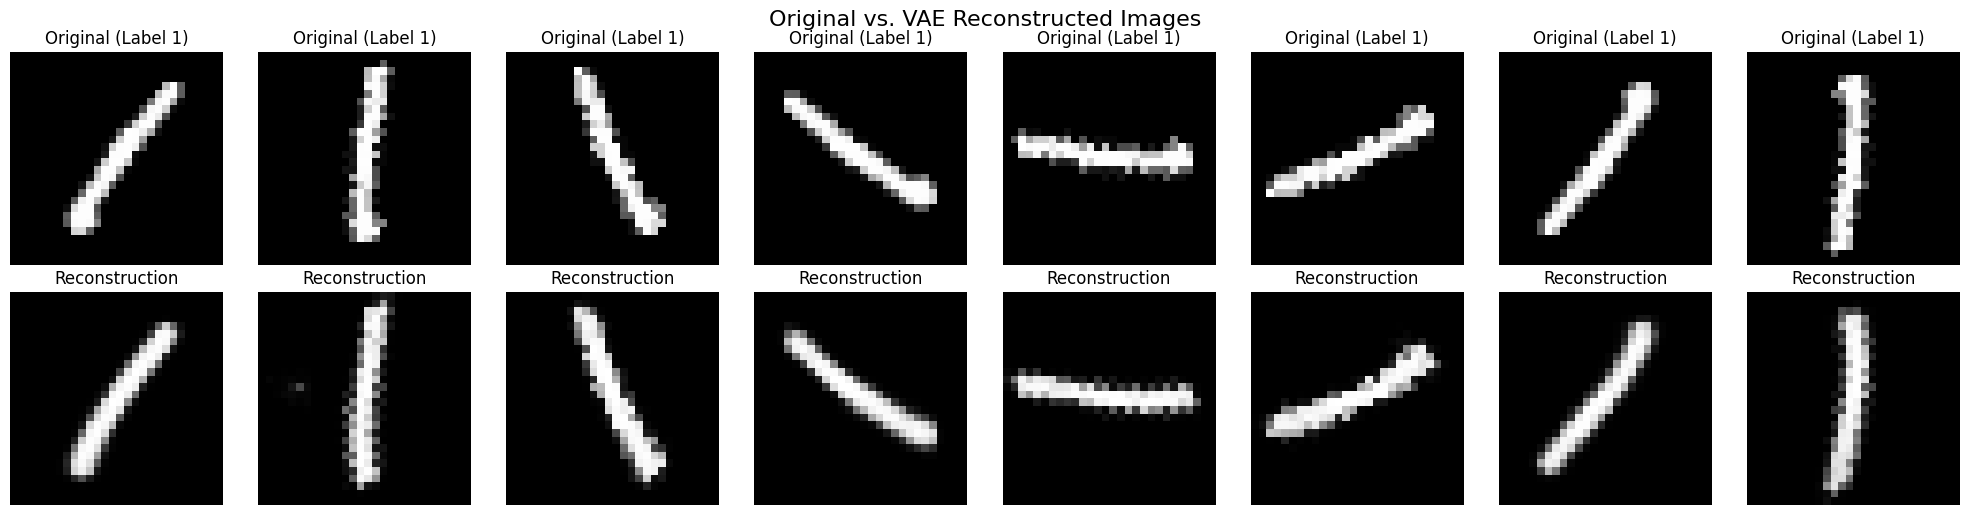

In [10]:
vae.eval() # Set model to evaluation mode

# 1. Plot 8 original images vs their VAE reconstructions
print("Generating original vs reconstructed images...")
num_samples_to_show = 8

fig, axes = plt.subplots(2, num_samples_to_show, figsize=(20, 5))

# Get a batch of data (preferably without shuffling for consistent display)
fixed_dataloader = DataLoader(mil_dataset, batch_size=num_samples_to_show, shuffle=False)
data_iter = iter(fixed_dataloader)
images, _, labels, _ = next(data_iter)
images = images.to(device)

with torch.no_grad():
    reconstructions, _, _ = vae(images)

for i in range(num_samples_to_show):
    # Original Image
    axes[0, i].imshow(images[i].cpu().squeeze().numpy(), cmap='gray')
    axes[0, i].set_title(f"Original (Label {labels[i].item()})")
    axes[0, i].axis('off')

    # Reconstructed Image
    axes[1, i].imshow(reconstructions[i].cpu().squeeze().numpy(), cmap='gray')
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle("Original vs. VAE Reconstructed Images", y=1.02, fontsize=16)
plt.show()

In [11]:
# 2. Encode all samples → collect all (z, mu, label, rotation_angle, original_image)
print("Collecting latent space representations...")
all_z = []
all_mu = []
all_labels = []
all_angles = []
all_original_images_tensor = [] # To store original image tensors

# Use a DataLoader with batch_size=256 and shuffle=False for consistent order
full_dataloader = DataLoader(mil_dataset, batch_size=256, shuffle=False)

with torch.no_grad():
    for batch_idx, (images, angles, labels, original_images) in enumerate(tqdm(full_dataloader, desc="Encoding all samples")):
        images = images.to(device)
        mu, log_var = vae.encode(images)
        z = vae.reparameterize(mu, log_var) # Using reparameterized z for t-SNE

        all_z.append(z.cpu())
        all_mu.append(mu.cpu())
        all_labels.append(labels.cpu())
        all_angles.append(angles.cpu())
        all_original_images_tensor.append(original_images.cpu()) # Store original image tensors

all_z = torch.cat(all_z, dim=0).numpy()
all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()
all_angles = torch.cat(all_angles, dim=0).numpy()
all_original_images_tensor = torch.cat(all_original_images_tensor, dim=0) # Keep as tensor

print(f"Collected latent vectors (z) shape: {all_z.shape}")
print(f"Collected means (mu) shape: {all_mu.shape}")
print(f"Collected labels shape: {all_labels.shape}")
print(f"Collected angles shape: {all_angles.shape}")
print(f"Collected original images tensor shape: {all_original_images_tensor.shape}")

Encoding all samples:   0%|          | 0/416 [00:00<?, ?it/s]

Collected latent vectors (z) shape: (106332, 32)
Collected means (mu) shape: (106332, 32)
Collected labels shape: (106332,)
Collected angles shape: (106332,)
Collected original images tensor shape: torch.Size([106332, 28, 28])


Performing t-SNE on latent space (colored by label)...
Using a random subset of 5000 samples for t-SNE.


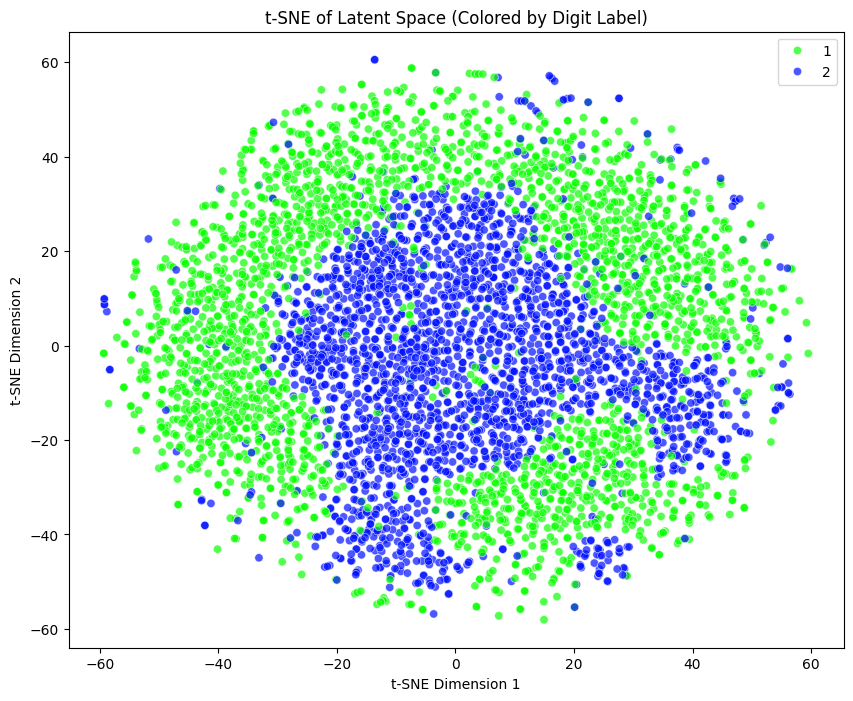

In [13]:
# 3. Plot t-SNE of latent space: colored by digit label (1 or 2)
print("Performing t-SNE on latent space (colored by label)...")

# Reduce the number of samples for t-SNE to speed up computation
sample_size = 5000 # Adjust as needed
if len(all_z) > sample_size:
    # Generate random indices for sampling
    np.random.seed(SEED) # Ensure reproducibility for sampling
    sample_indices = np.random.choice(len(all_z), sample_size, replace=False)

    sampled_z = all_z[sample_indices]
    sampled_labels = all_labels[sample_indices]
    sampled_angles = all_angles[sample_indices]
    print(f"Using a random subset of {sample_size} samples for t-SNE.")
else:
    sampled_z = all_z
    sampled_labels = all_labels
    sampled_angles = all_angles

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
latent_tsne_labels = tsne.fit_transform(sampled_z)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=latent_tsne_labels[:, 0],
    y=latent_tsne_labels[:, 1],
    hue=sampled_labels,
    palette=sns.color_palette("hsv", n_colors=len(np.unique(sampled_labels))),
    legend='full',
    alpha=0.7
)
plt.title('t-SNE of Latent Space (Colored by Digit Label)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

# Make sampled_angles available for the next cell
# If a full run, sampled_angles will be identical to all_angles
# This ensures the next cell can use `sampled_angles` directly
all_angles = sampled_angles

Performing t-SNE on latent space (colored by rotation angle)...


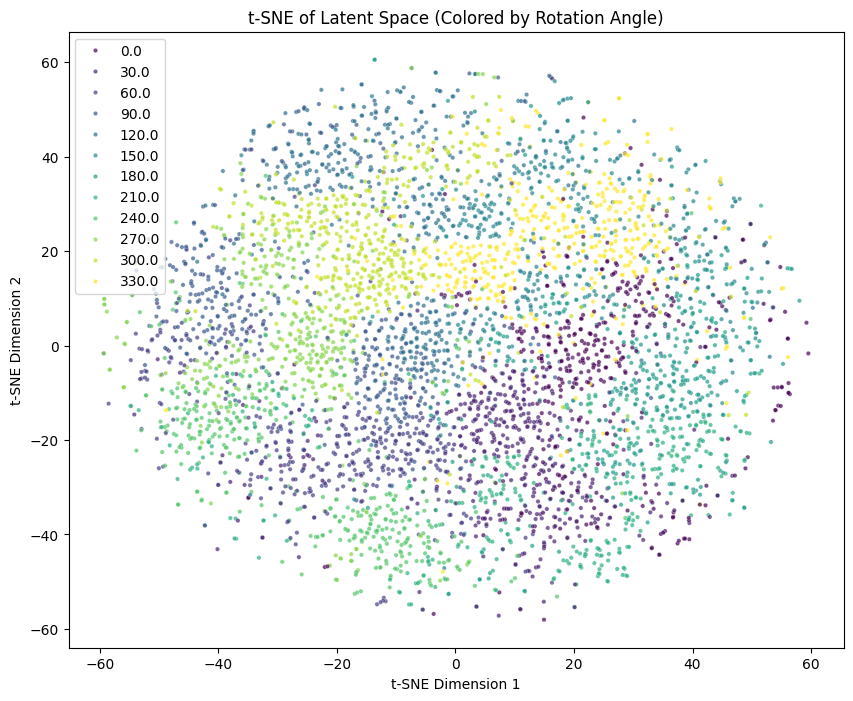

In [14]:
# 4. Plot t-SNE of latent space: colored by rotation angle (0° to 330°)
print("Performing t-SNE on latent space (colored by rotation angle)...")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=latent_tsne_labels[:, 0], # Using the same transformed data from the previous t-SNE fit
    y=latent_tsne_labels[:, 1],
    hue=all_angles,
    palette='viridis',
    legend='full',
    alpha=0.7,
    s=10 # Smaller point size for potentially many unique angles
)
plt.title('t-SNE of Latent Space (Colored by Rotation Angle)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

## STEP 6 — EXPORT TO GOOGLE DRIVE

This final step mounts Google Drive and saves the trained model components (encoder and decoder weights) and the collected latent space data to a specified directory.

In [15]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the base save path
save_path = '/content/drive/MyDrive/gsoc_symmetry/'

# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)
print(f"Save directory created at: {save_path}")

# Save encoder weights (saving the full VAE state dict for simplicity)
encoder_weights_path = os.path.join(save_path, 'encoder.pth')
torch.save(vae.state_dict(), encoder_weights_path)
print(f"Encoder weights (full VAE state dict) saved to: {encoder_weights_path}")

# Save decoder weights (saving the full VAE state dict for simplicity)
decoder_weights_path = os.path.join(save_path, 'decoder.pth')
torch.save(vae.state_dict(), decoder_weights_path)
print(f"Decoder weights (full VAE state dict) saved to: {decoder_weights_path}")

# Save all latent vectors + metadata
latents_data = {
    'z': torch.tensor(all_z, dtype=torch.float32),
    'mu': torch.tensor(all_mu, dtype=torch.float32),
    'label': torch.tensor(all_labels, dtype=torch.long),
    'angle': torch.tensor(all_angles, dtype=torch.float32),
    'original_image': all_original_images_tensor # Already a tensor
}

latents_path = os.path.join(save_path, 'latents.pt')
torch.save(latents_data, latents_path)
print(f"Latent vectors and metadata saved to: {latents_path}")

print("All required files have been saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory created at: /content/drive/MyDrive/gsoc_symmetry/
Encoder weights (full VAE state dict) saved to: /content/drive/MyDrive/gsoc_symmetry/encoder.pth
Decoder weights (full VAE state dict) saved to: /content/drive/MyDrive/gsoc_symmetry/decoder.pth
Latent vectors and metadata saved to: /content/drive/MyDrive/gsoc_symmetry/latents.pt
All required files have been saved to Google Drive.
